<a href="https://colab.research.google.com/github/pkorotkow/statprak/blob/main/statprak5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Preprocessing

In [ ]:
import pandas as pd
import numpy as np

In [ ]:
all_data = pd.read_csv('forest_dataset.csv')
all_data.head()

In [ ]:
all_data.shape

In [ ]:
labels = all_data[all_data.columns[-1]].values
feature_matrix = all_data[all_data.columns[:-1]].values

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
train_feature_matrix, test_feature_matrix, train_labels, test_labels = train_test_split(
    feature_matrix, labels, test_size=0.2, random_state=42)

# Homework

Train the `KNeighborsClassifier` on the dataset.

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

clf = KNeighborsClassifier()
clf.fit(train_feature_matrix, train_labels)

Let's select the parameters of our model:

* Iterate over the grid from `1` to `10` for the number of neighbors parameter
* Also, try using different metrics: `['manhattan', 'euclidean']`
* Try using different weight calculation strategies: `[‘uniform’, ‘distance’]`

In [9]:
from sklearn.model_selection import GridSearchCV
params = {'n_neighbors': [i for i in range(1, 11)], 'metric' : ['manhattan', 'euclidean'], 'weights': ['uniform','distance']}

clf_grid = GridSearchCV(clf, params, cv=5, scoring='accuracy', n_jobs=-1)
clf_grid.fit(train_feature_matrix, train_labels)

GridSearchCV(cv=5, estimator=KNeighborsClassifier(), n_jobs=-1,
             param_grid={'metric': ['manhattan', 'euclidean'],
                         'n_neighbors': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
                         'weights': ['uniform', 'distance']},
             scoring='accuracy')

Let's output the best parameters

In [10]:
clf_grid.best_params_

{'metric': 'manhattan', 'n_neighbors': 4, 'weights': 'distance'}

Using the optimal number of neighbors found, calculate the probabilities of belonging to classes for the test sample (`.predict_proba`).

In [12]:
optimal_clf = KNeighborsClassifier(metric = 'manhattan', n_neighbors = 4, weights = 'distance')
optimal_clf.fit(train_feature_matrix, train_labels)
pred_prob = optimal_clf.predict_proba(test_feature_matrix)

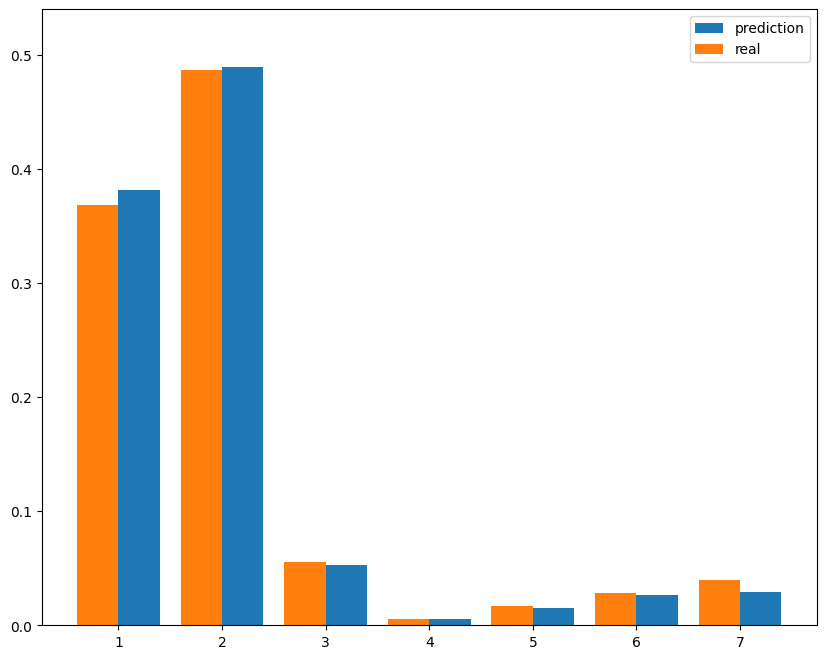

In [13]:
import matplotlib.pyplot as plt
%matplotlib inline
import numpy as np

unique, freq = np.unique(test_labels, return_counts=True)
freq = list(map(lambda x: x / len(test_labels),freq))

pred_freq = pred_prob.mean(axis=0)
plt.figure(figsize=(10, 8))
plt.bar(range(1, 8), pred_freq, width=0.4, align="edge", label='prediction')
plt.bar(range(1, 8), freq, width=-0.4, align="edge", label='real')
plt.ylim(0, 0.54)
plt.legend()
plt.show()

## Conclusion

What is the quality of the model on the test sample? Compare it with the quality of logistic regression. Which model is better? Why? What are the pros and cons of the k Nearest Neighbors method? Plot the ROC curve for the k Nearest Neighbors method. Calculate the area under the ROC curve (AUC-ROC).

Качество модели получилось очень хорошее, предсказание очень слабо отличается от реальных ответов. Посчитаем метрику accuracy:

In [14]:
pred_labels = optimal_clf.predict(test_feature_matrix)
accuracy = accuracy_score(test_labels, pred_labels)
print(accuracy)

0.7845


Для логистической регрессии accuracy был равен 0.642, то есть на 14% меньше. Получается, kNN справился с задачей лучше. Скорее всего это связано с тем, что логистическая регерссия является линейным классификатором, а конкретно данный датассет плохо разделяется с помощью гиперплоскости. В то же время kNN без разницы на тип зависимости, он просто смотрит на соседей и из этого делает выводы

**Получаем следующие плюсы и минусы kNN:**

Плюсы:
+ Высокая точность на сложных данных (которые имеют неочевидные зависимости)
+ Не делаем заранее предположений о распределении данных (как делаем в линейных классификаторах)
+ Он легко интерпретируем, так как просто действуем по правилу "Посмотрю на друга и скажу кто ты"

Минусы:
- Очень много вычислений (должны посчитать все расстояния), из-за чего достаточно долгий
- Нужно много памяти, так как должны хранить все расстояния
- (Gemini написал, что он чувствителен к масштабу признаков, но вроде как тут мы это явно не проверяли)



Общий AUC-ROC: 0.9063


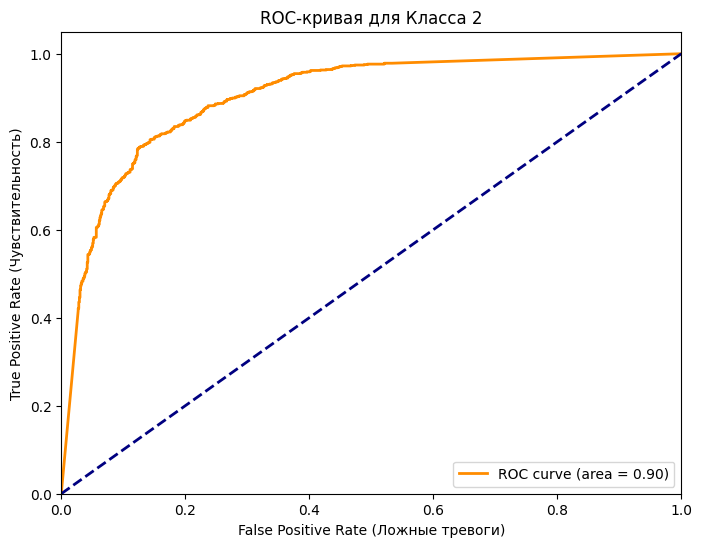

In [15]:
from sklearn.metrics import roc_curve, auc, roc_auc_score
import matplotlib.pyplot as plt

#Так как ROC-AUC работает только с двумя классами, а меня попросили посчитать, то, как я понял,
#нужно использоваться "One-vs-Rest", то есть один против всех, когда считают AUC-ROC отдельно для класса и оставшихся,
#после чего результат усредняется
overall_auc = roc_auc_score(test_labels, pred_prob, multi_class='ovr')
print(f"Общий AUC-ROC: {overall_auc:.4f}")

# 2. Так как кривая строится только для одного класса, построим кривую для класса 2
binary_labels = (test_labels == 2).astype(int)
fpr, tpr, _ = roc_curve(binary_labels, pred_prob[:, 1])
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--') # Линия удачи
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC-кривая для Класса 2')
plt.legend(loc="lower right")
plt.show()

Получился очень хороший результат AUC, значит модель реально качественно способна отделять один класс от другого (как минимум класс номер два от остальных)